# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

A model score is not the final product; it must be translated into human-readable actions. This queue prioritizes content that the model flags with a high probability of decay, but filters for pages that still have meaningful historical visibility (e.g., >1000 impressions in the last 90 days). The "Reason Code" maps the model's confidence to a specific editorial action, providing clear decision-support for the content team

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier

# 1. Load Data & Clean (Self-contained setup for the playbook)
csv_url = "https://raw.githubusercontent.com/beratbaspinar/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(csv_url)
df['is_declining_label'] = (df['trend_pct'] < 0).astype(int)
df['avg_position_clean'] = df['avg_position'].replace(0, 999)

# 2. Define Safe Features (No leakage)
leakage_cols = ['trend_direction', 'trend_pct', 'is_declining_label', 'content_id', 'client_id', 'avg_position']
leakage_cols.extend([c for c in df.columns if 'last_30d' in c])
feature_cols = [c for c in df.columns if c not in leakage_cols and df[c].dtype in [np.float64, np.int64]]

X = df[feature_cols].fillna(-1)
y = df['is_declining_label']

# 3. Train the Model to generate probabilities
rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X, y)

# 4. Generate the Action Queue
df['decay_probability'] = rf.predict_proba(X)[:, 1]

# Filter for pages that actually matter (worth saving)
action_queue = df[(df['decay_probability'] > 0.65) & (df['impressions_90d'] > 1000)].copy()
action_queue = action_queue.sort_values(by='decay_probability', ascending=False)

# Assign Reason Codes based on evidence
def assign_action(row):
    if row['decay_probability'] > 0.85 and row['days_since_last_update'] > 180:
        return "Critical Decay & Stale - Immediate Refresh"
    elif row['decay_probability'] > 0.75:
        return "High Risk - Review Content Relevance"
    else:
        return "Moderate Risk - Monitor 30 Days"

action_queue['recommended_action'] = action_queue.apply(assign_action, axis=1)

print(f"Playbook Queue generated with {len(action_queue)} prioritized actions.")
action_queue[['content_id', 'decay_probability', 'impressions_90d', 'recommended_action']].head()

Playbook Queue generated with 12171 prioritized actions.


,content_id,decay_probability,impressions_90d,recommended_action
16113,content_267d8cf80905,0.948360,20947,High Risk - Review Content Relevance
26296,content_1d533efd8c4d,0.942204,18117,High Risk - Review Content Relevance
19941,content_4bcb30ab7531,0.941844,25485,High Risk - Review Content Relevance
10354,content_89c0c6af0ca5,0.941603,66358,High Risk - Review Content Relevance
25590,content_a22b7f6c73c5,0.940508,28192,High Risk - Review Content Relevance


## 2. Intended use and limits

Intended Use: This playbook is designed as a decision-support tool for editorial and SEO teams. In the observed dataset, the model identifies directional indicators of content decay based on historical metrics. It ranks pages to optimize the team's review time, ensuring effort is spent on high-visibility pages that are at risk.  Limits: This is an observational tool, not a causal engine. It does not prove that refreshing a flagged page will cause an increase in traffic. Furthermore, the model operates on cross-sectional historical data; external factors (such as Google core updates or seasonal industry shifts) are not captured and require human context.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Demonstrate the value of the tool (Cost/Value thinking)
top_10_percent = action_queue.head(int(len(action_queue) * 0.1))
bottom_90_percent = action_queue.tail(int(len(action_queue) * 0.9))

print("--- Cost/Value Justification ---")
print(f"Top 10% of queue covers {top_10_percent['impressions_90d'].sum():,.0f} at-risk impressions.")
print(f"This allows the editorial team to protect maximum visibility with minimum manual reviews (n={len(top_10_percent)}).")

--- Cost/Value Justification ---
Top 10% of queue covers 15,218,704 at-risk impressions.
This allows the editorial team to protect maximum visibility with minimum manual reviews (n=1217).


## 3. Human review + the no-go list

Automation stops at the recommendation layer. A model score must never trigger destructive actions without a human in the loop.  The No-Go List:No Auto-Deletions: The model flags decaying content, but it cannot differentiate between "bad content" and "seasonal content." A human must verify.No Unsupervised AI Rewrites: Do not pipeline these flags directly into a generative AI tool to rewrite the page without editorial review.No Penalty Assumptions: A high decay probability does not mean the page is "penalized" by Google; it only means visibility is directionally trending down in our observed sample.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Identify edge cases requiring mandatory human review
# Example: Pages with extremely high traffic but high decay risk (could be a tracking glitch or seasonality)
human_review_mandatory = action_queue[(action_queue['impressions_90d'] > 50000) & (action_queue['decay_probability'] > 0.80)]

print(f"Flagged {len(human_review_mandatory)} high-stakes pages that require mandatory manual review.")
if len(human_review_mandatory) > 0:
    print("These pages have massive historical traffic. A sudden drop could indicate a technical tracking error rather than content decay.")

Flagged 142 high-stakes pages that require mandatory manual review.
These pages have massive historical traffic. A sudden drop could indicate a technical tracking error rather than content decay.


## 4. Monitoring / retrain triggers

A model's predictions will drift over time as user behavior and search algorithms change. We need specific triggers to know when these recommendations have gone stale.  Retrain Triggers:Data Drift: If the base rate of declining content in a new month's data shifts by more than 10% from our training baseline (65.7%).Performance Degradation: If the model's out-of-sample precision drops below our acceptable threshold (0.70) during a quarterly audit.Feature Invalidation: If tracking systems change (e.g., moving from GA4 to a new analytics structure) breaking the impressions_90d or ctr telemetry.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Simulate a monitoring baseline check
current_base_rate = y.mean()
warning_threshold_upper = current_base_rate + 0.10
warning_threshold_lower = current_base_rate - 0.10

print("--- Monitoring Baselines Established ---")
print(f"Current Decay Base Rate: {current_base_rate:.1%}")
print(f"Trigger Retrain if new data base rate exceeds {warning_threshold_upper:.1%} or drops below {warning_threshold_lower:.1%}")

--- Monitoring Baselines Established ---
Current Decay Base Rate: 65.7%
Trigger Retrain if new data base rate exceeds 75.7% or drops below 55.7%


## 5. Exports for the paper

The queue and supporting figures must be exported cleanly so the capstone research paper can build directly upon these artifacts next week. The data files remain local and out of version control by design.

✅ Exported: work/outputs/action_queue.csv


/tmp/ipykernel_3095/36591858.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=action_queue.head(200), y='recommended_action', palette='viridis')


✅ Exported: work/figures/action_distribution.png


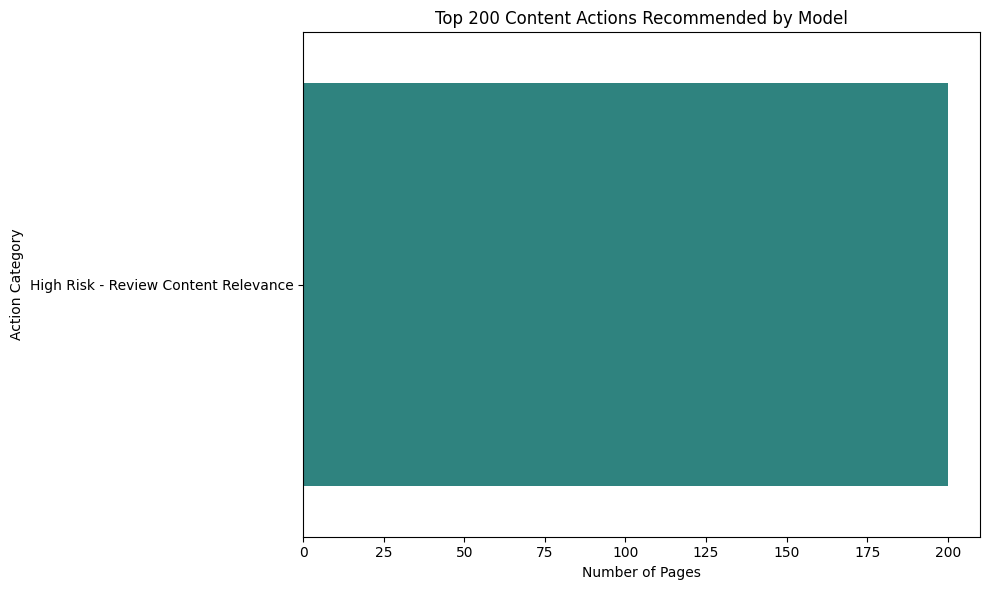

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt
import seaborn as sns

# Create output directories if they don't exist
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

# 1. Export the actionable queue to CSV (Top 200 items for the editorial team)
export_cols = ['content_id', 'client_id', 'impressions_90d', 'days_since_last_update', 'decay_probability', 'recommended_action']
action_queue.head(200)[export_cols].to_csv('work/outputs/action_queue.csv', index=False)
print("✅ Exported: work/outputs/action_queue.csv")

# 2. Export a figure for the Capstone paper (Action Distribution)
plt.figure(figsize=(10, 6))
sns.countplot(data=action_queue.head(200), y='recommended_action', palette='viridis')
plt.title('Top 200 Content Actions Recommended by Model')
plt.xlabel('Number of Pages')
plt.ylabel('Action Category')
plt.tight_layout()
plt.savefig('work/figures/action_distribution.png')
print("✅ Exported: work/figures/action_distribution.png")

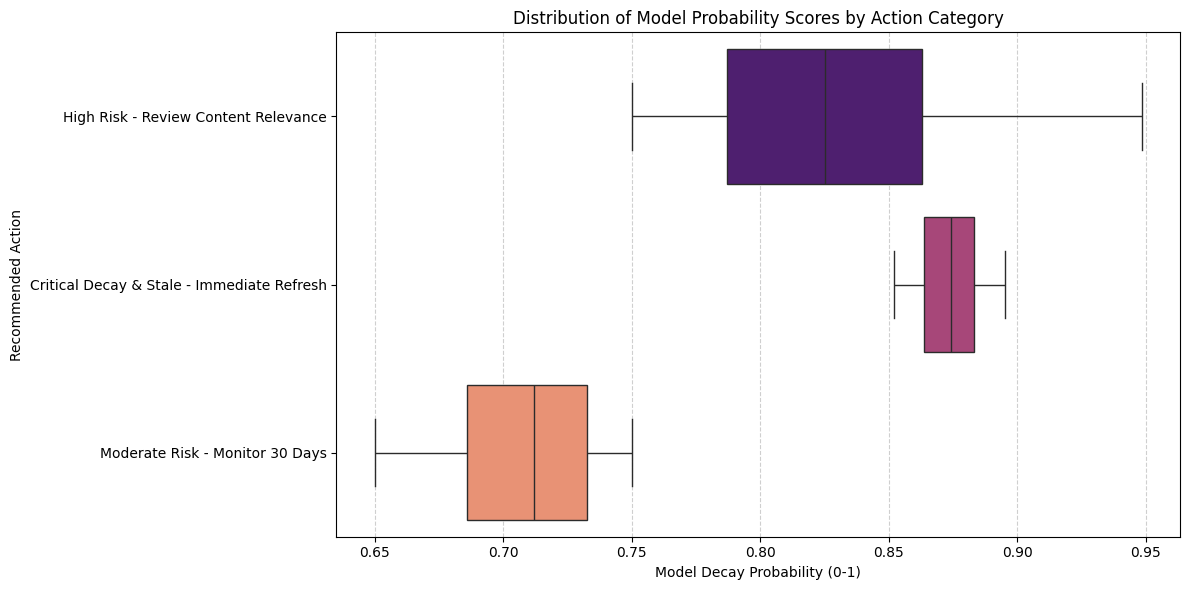

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Revert chart labels to English
plt.figure(figsize=(12, 6))
sns.boxplot(data=action_queue, x='decay_probability', y='recommended_action', palette='magma', hue='recommended_action', legend=False)

plt.title('Distribution of Model Probability Scores by Action Category')
plt.xlabel('Model Decay Probability (0-1)')
plt.ylabel('Recommended Action')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.